In [ ]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os
if 'google.colab' in sys.modules:
    if not os.path.exists('/content/my_PRML'):
        print("リポジトリをダウンロード中...")
        !git clone https://github.com/miyayudai/my_PRML.git > /dev/null 2>&1
    
    print("必要なモジュールをインストール中...")
    %cd /content/my_PRML
    !pip install -q -r requirements.txt
    !pip install -q -e .
    
    print("作業ディレクトリをセットアップ中...")
    %cd /content/my_PRML/6
    print("準備完了！このまま下のセルを実行できます。")

# 6.3 放射基底関数ネットワークと Nadaraya-Watson モデル (RBF Networks and Nadaraya-Watson)

本ノートブックでは、入力空間の局所的な参照点との距離のみに依存する**放射基底関数 (Radial Basis Functions: RBF)** ネットワークと、ノンパラメトリックな核密度推定から自然に導かれる**Nadaraya-Watson カーネル回帰モデル**を学びます。
正規化された放射基底関数の特性（**PRML Figure 6.2**）、結合確率密度推定量からの条件付き期待値の厳密な導出、および正弦波データに対する平滑化挙動（**PRML Figure 6.3**）を完全実装します。

## 6.3 放射基底関数と正規化 (Normalized RBF, PRML Figure 6.2)

入力ベクトル $\mathbf{x}$ と中心点 $\boldsymbol{\mu}_j$ のユークリッド距離のみに依存する基底関数 $\phi_j(\mathbf{x}) = h(\|\mathbf{x} - \boldsymbol{\mu}_j\|)$ を放射基底関数と呼びます。典型例はガウス基底です：
$$ \phi_j(\mathbf{x}) = \exp\left( -\frac{\|\mathbf{x} - \boldsymbol{\mu}_j\|^2}{2\sigma^2} \right) $$
これらの総和を1に規格化した**正規化放射基底関数 (Normalized RBF)**：
$$ \psi_j(\mathbf{x}) = \frac{\phi_j(\mathbf{x})}{\sum_k \phi_k(\mathbf{x})} $$
は、入力空間の任意の点において総和が1となり、区分的な補間特性が向上します（**PRML Figure 6.2**）。

Plot saved to: result/fig6_2_normalized_rbf.png


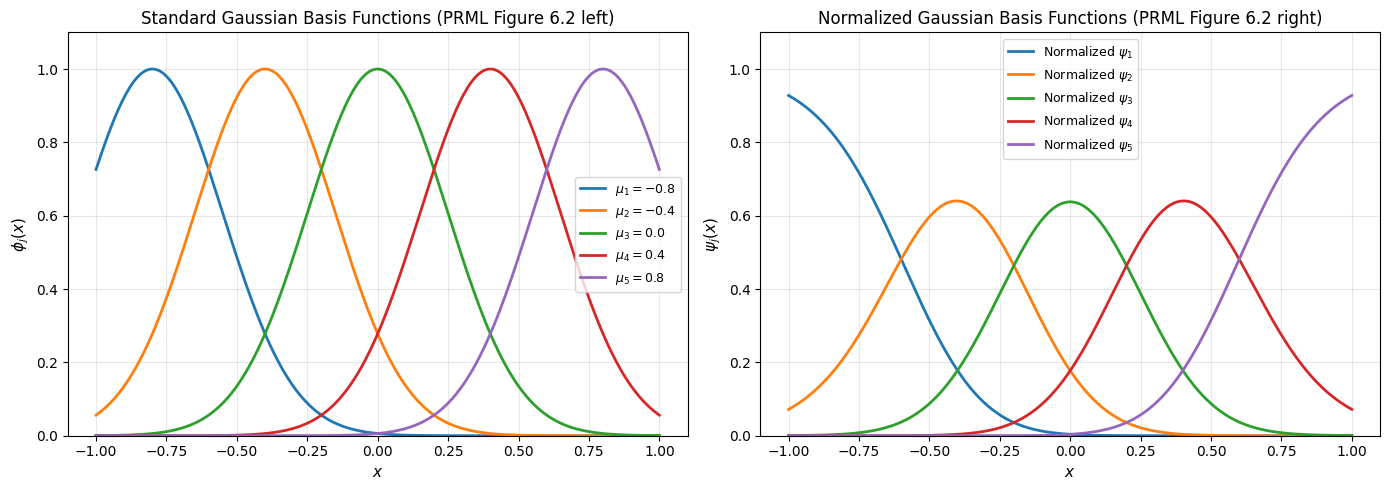

In [1]:
import sys, os
sys.path.append(os.path.abspath('../'))
import numpy as np
import matplotlib.pyplot as plt
from common.plot_utils import save_plot, setup_style
setup_style()

# PRML Figure 6.2 の完全再現
x = np.linspace(-1, 1, 300)
centers = np.linspace(-0.8, 0.8, 5)
sigma = 0.25

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) 標準的なガウス基底
basis_matrix = np.zeros((len(x), len(centers)))
for j, mu in enumerate(centers):
    phi_j = np.exp(-0.5 * (x - mu)**2 / sigma**2)
    basis_matrix[:, j] = phi_j
    axes[0].plot(x, phi_j, lw=2, label=rf'$\mu_{j+1} = {mu:.1f}$')

axes[0].set_title('Standard Gaussian Basis Functions (PRML Figure 6.2 left)', fontsize=12)
axes[0].set_xlabel('$x$', fontsize=11); axes[0].set_ylabel('$\phi_j(x)$', fontsize=11)
axes[0].set_ylim(0, 1.1); axes[0].grid(True, alpha=0.3); axes[0].legend(fontsize=9)

# (b) 正規化されたガウス基底
normalized_basis = basis_matrix / np.sum(basis_matrix, axis=1, keepdims=True)
for j, mu in enumerate(centers):
    axes[1].plot(x, normalized_basis[:, j], lw=2, label=rf'Normalized $\psi_{j+1}$')

axes[1].set_title('Normalized Gaussian Basis Functions (PRML Figure 6.2 right)', fontsize=12)
axes[1].set_xlabel('$x$', fontsize=11); axes[1].set_ylabel('$\psi_j(x)$', fontsize=11)
axes[1].set_ylim(0, 1.1); axes[1].grid(True, alpha=0.3); axes[1].legend(fontsize=9)

plt.tight_layout()
save_plot(fig, 'result', 'fig6_2_normalized_rbf.png')
plt.show()

## 6.3.1 Nadaraya-Watson カーネル回帰モデル (PRML Figure 6.3)

学習データセット $\{\mathbf{x}_n, t_n\}_{n=1}^N$ に対し、Parzen窓法（カーネル密度推定）を用いて結合確率密度 $p(\mathbf{x}, t)$ をモデル化します：
$$ p(\mathbf{x}, t) = \frac{1}{N} \sum_{n=1}^N g(\mathbf{x} - \mathbf{x}_n, t - t_n) $$
ここでカーネル関数 $g(\mathbf{x}, t) = f(\mathbf{x}) q(t)$ が平均 0 のガウス分布であると仮定します。
このとき、条件付き期待値（二乗損失における最適回帰関数）は：
$$ y(\mathbf{x}) = \mathbb{E}[t|\mathbf{x}] = \int t p(t|\mathbf{x}) dt = \frac{\int t p(\mathbf{x}, t) dt}{\int p(\mathbf{x}, t) dt} $$
$$ = \frac{\sum_{n=1}^N f(\mathbf{x} - \mathbf{x}_n) \int t q(t - t_n) dt}{\sum_{m=1}^N f(\mathbf{x} - \mathbf{x}_m) \int q(t - t_m) dt} = \frac{\sum_{n=1}^N f(\mathbf{x} - \mathbf{x}_n) t_n}{\sum_{m=1}^N f(\mathbf{x} - \mathbf{x}_m)} $$
$$ y(\mathbf{x}) = \sum_{n=1}^N k(\mathbf{x}, \mathbf{x}_n) t_n, \quad k(\mathbf{x}, \mathbf{x}_n) = \frac{f(\mathbf{x} - \mathbf{x}_n)}{\sum_m f(\mathbf{x} - \mathbf{x}_m)} $$
この $k(\mathbf{x}, \mathbf{x}_n)$ を**Nadaraya-Watson カーネル**（等価カーネル）と呼び、$\sum_n k(\mathbf{x}, \mathbf{x}_n) = 1$ を常に満たします。

### 条件付き分散 (不確実性)
$$ \mathrm{Var}[t|\mathbf{x}] = \mathbb{E}[t^2|\mathbf{x}] - \mathbb{E}[t|\mathbf{x}]^2 = \sigma_0^2 + \sum_{n=1}^N k(\mathbf{x}, \mathbf{x}_n) t_n^2 - y(\mathbf{x})^2 $$
これにより、点予測だけでなく予測の不確実性も同時に得ることができます。

Plot saved to: result/fig6_3_nadaraya_watson.png


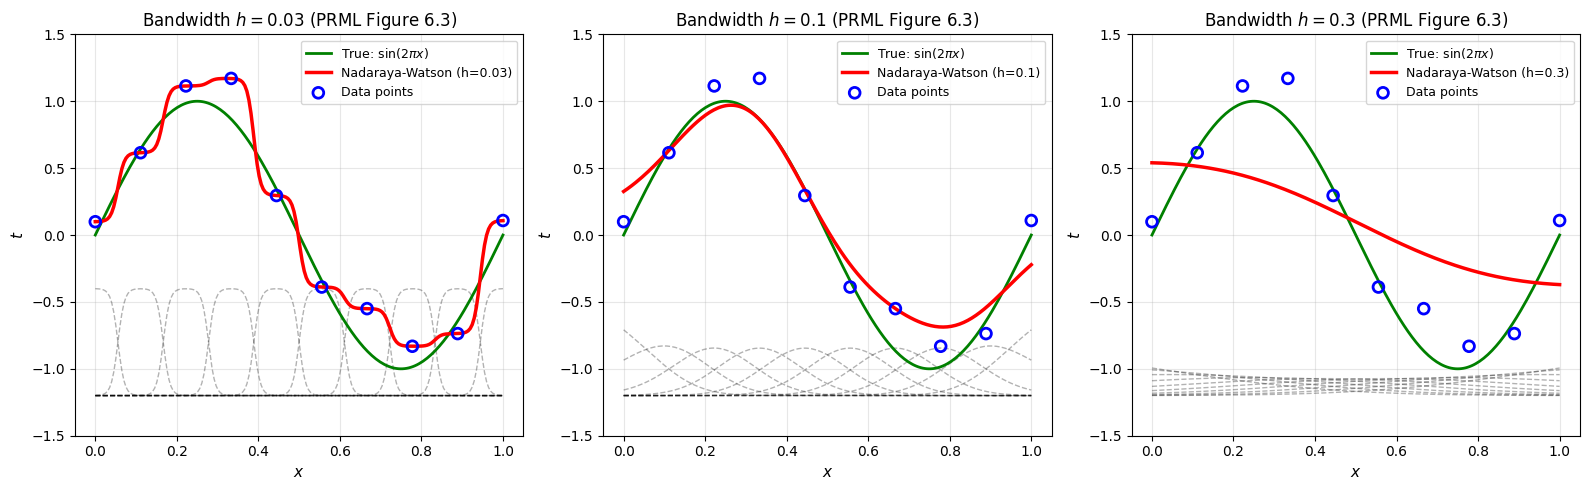

In [2]:
from common.kernel_utils import NadarayaWatsonRegressor, rbf_kernel

# PRML Figure 6.3 の完全再現
np.random.seed(42)
N_data = 10
x_train = np.linspace(0, 1, N_data)
t_train = np.sin(2 * np.pi * x_train) + np.random.normal(0, 0.2, N_data)

x_plot = np.linspace(0, 1, 200)
y_true = np.sin(2 * np.pi * x_plot)

# 帯域幅 (length_scale) の比較
bandwidths = [0.03, 0.1, 0.3]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, h in enumerate(bandwidths):
    ax = axes[idx]
    nw = NadarayaWatsonRegressor(kernel=rbf_kernel, length_scale=h)
    nw.fit(x_train.reshape(-1, 1), t_train)
    y_pred = nw.predict(x_plot.reshape(-1, 1))
    
    # 局所重み（特定サンプルに対する等価カーネル）
    K_weights = rbf_kernel(x_plot.reshape(-1, 1), x_train.reshape(-1, 1), length_scale=h)
    K_weights /= np.sum(K_weights, axis=1, keepdims=True)
    # 代表的な等価カーネルを点線で描画
    for n in range(N_data):
        ax.plot(x_plot, K_weights[:, n] * 0.8 - 1.2, 'k--', alpha=0.3, lw=1.0)
        
    ax.plot(x_plot, y_true, 'g-', lw=2.0, label='True: $\sin(2\pi x)$')
    ax.plot(x_plot, y_pred, 'r-', lw=2.5, label=f'Nadaraya-Watson (h={h})')
    ax.scatter(x_train, t_train, facecolors='none', edgecolors='b', s=60, lw=2, label='Data points', zorder=5)
    
    ax.set_title(rf'Bandwidth $h = {h}$ (PRML Figure 6.3)', fontsize=12)
    ax.set_xlabel('$x$', fontsize=11); ax.set_ylabel('$t$', fontsize=11)
    ax.set_ylim(-1.5, 1.5)
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
save_plot(fig, 'result', 'fig6_3_nadaraya_watson.png')
plt.show()